In [29]:
import os
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [30]:
import sys
import os
sys.path.append(os.path.abspath('..'))
try:
    from utils import neighbourhood_graph, compute_similarities_1vsAll, compute_distances_1vsAll
except ImportError:
    pass # Adjust if your utils.py is located differently
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import pickle

# Setup your path logic dynamically
product_id = "210036"
metric = "cid"  # Change to 'cid' or other metrics as needed
window_size = 15
step = 1
threshold = "2.5"  # Adjust threshold as needed for CID
ENABLE_Z_NORMALIZATION = True # Flag to enable/disable Z-score normalization

# Ensure this path matches where graph_lstm.py saves the pkls
pkl_path = f"DynamicGraphPkls/{product_id}/{metric}/{window_size}/{step}/th{threshold}/dynamic_graphs_{metric}_Window{window_size}_Step{step}_th{threshold}.pkl"

graphs = []
if os.path.exists(pkl_path):
    print(f"Loading graphs from: {pkl_path}")
    with open(pkl_path, 'rb') as f:
        graphs = pickle.load(f)
    print(f"Successfully loaded {len(graphs)} sliding window graphs.")
else:
    print(f"File not found: {pkl_path}")
    print("Generating them dynamically...")
    
    DATA_PATH = "../../../dataset/data_andre.feather"
    if os.path.exists(DATA_PATH):
        df_raw = pd.read_feather(DATA_PATH)
        cat_labels_dict = df_raw.drop_duplicates('item_id').set_index('item_id')['cat_label'].to_dict()
        df_wide = df_raw.pivot_table(index='item_id', columns='date', values='value', aggfunc='sum').fillna(0)
        
        # Dynamically switch between distance and similarity logic
        distance_metrics = ['cid', 'dtw', 'euclidean', 'manhattan', 'lorentzian', 'amplitude_offset', 'slope_consistency', 'phase_invariance']
        is_distance = metric in distance_metrics
        
        comp_func = compute_distances_1vsAll if is_distance else compute_similarities_1vsAll
        m_type = "distance" if is_distance else "similarity"
        
        if ENABLE_Z_NORMALIZATION:
            print("Applying Z-score normalization...")
            # Replicating the train slice from graph2vec_lstm.py
            L = len(df_wide.columns)
            forecast_horizon_global = 152
            val_size_global = 154
            train_size_global = 455
            global_train_start_idx = max(0, L - forecast_horizon_global - val_size_global - train_size_global)
            global_val_start_idx = L - forecast_horizon_global - val_size_global

            train_df_wide = df_wide.iloc[:, global_train_start_idx:global_val_start_idx]

            # Apply z-normalization identically to graph2vec_lstm.py
            df_wide_scaled = df_wide.copy()
            
            for item_id_iter in df_wide.index:
                z_scaler = StandardScaler()
                # fit on training window for this item
                train_ts = train_df_wide.loc[item_id_iter].values.reshape(-1, 1)
                z_scaler.fit(train_ts)
                
                # Transform the entire continuous history for the graph
                full_ts = df_wide.loc[item_id_iter].values.reshape(-1, 1)
                df_wide_scaled.loc[item_id_iter] = z_scaler.transform(full_ts).flatten()
                
            # Only use scaled dataframe if distance metric AND normalization is enabled
            current_df_wide = df_wide_scaled if is_distance else df_wide
        else:
            print("Z-score normalization is disabled. Using raw values.")
            current_df_wide = df_wide
        
        graphs, global_threshold = neighbourhood_graph(
            product_id=int(product_id),
            metric_type=m_type,
            compute_func=comp_func, 
            df=current_df_wide, 
            metric=metric, 
            window_size=window_size, 
            threshold=float(threshold),
            percentile=None,
            step_size=step, 
            cat_labels=cat_labels_dict,
            plot_dir=None,
            residuals=False,
            enable_edges_within_star=True,
            enable_second_degree=False,  
            num_plots=0
        )
        print(f"Dynamically calculated {len(graphs)} sliding window graphs!")
    else:
        print(f"Could not find DATA_PATH: {DATA_PATH}. Cannot generate graphs dynamically.")

# Restrict graphs list to Train and Validation sets only (removing the test period)
forecast_horizon_global = 152
if len(graphs) > forecast_horizon_global:
    graphs = graphs[:-forecast_horizon_global]
    print(f"Filtered to Train and Validation sets. Remaining graphs: {len(graphs)}")

File not found: DynamicGraphPkls/210036/cid/15/1/th2.5/dynamic_graphs_cid_Window15_Step1_th2.5.pkl
Generating them dynamically...
Applying Z-score normalization...
Building 747 sliding window graphs...
  Built 747/747 graphs...
Dynamically calculated 747 sliding window graphs!
Filtered to Train and Validation sets. Remaining graphs: 595


In [31]:
# Make sure we point correctly up 3 levels from GraphAnalysis to Dissertation25-26
DATA_PATH = "../../../dataset/data_andre.feather"

df = pd.DataFrame()
if os.path.exists(DATA_PATH):
    print(f"Loading actual dates from: {DATA_PATH}")
    df = pd.read_feather(DATA_PATH)
    df = df[df['item_id'] == int(product_id)].sort_values('date').reset_index(drop=True)
else:
    print(f"Could not find {DATA_PATH}. Check path strictly!")

if graphs:
    stats = []
    
    # We map the i-th step to the date at the END of the window 
    # (since the first window ends on the window_size-th day)
    for i, g in enumerate(graphs):
        num_nodes = g.number_of_nodes()
        num_edges = g.number_of_edges()
        density = nx.density(g)
        isolates = list(nx.isolates(g))
        
        # Get distances to target product (edges connected to product_id)
        # Note: central product is stored as string/int depending on logic, let's use list(g.nodes)[0] or verify logic.
        target_node = product_id if product_id in g else int(product_id)
        
        distances = []
        if target_node in g:
            for _, _, d in g.edges(target_node, data=True):
                # The weight for star-edges is exactly the raw val_sub computed
                if 'weight' in d:
                    distances.append(d['weight'])
                    
        worst_dist = np.max(distances) if distances else 0.0
        
        # Calculate window end date (the actual day the sliding window prediction/representation corresponds to)
        end_idx = i * step + window_size - 1
        real_date = df['date'].iloc[end_idx] if not df.empty and end_idx < len(df) else i
        
        stats.append({
            'TimeStep': i,
            'Date': real_date,
            'NumNodes': num_nodes,
            'NumEdges': num_edges,
            'Density': density,
            'Isolates': len(isolates),
            'WorstDistance': worst_dist
        })
        
    df_stats = pd.DataFrame(stats)
    if 'Date' in df_stats.columns and not df.empty:
        df_stats['Date'] = pd.to_datetime(df_stats['Date'])
        
    display(df_stats.head())

Loading actual dates from: ../../../dataset/data_andre.feather


,TimeStep,Date,NumNodes,NumEdges,Density,Isolates,WorstDistance
0,0,2021-02-06,1,0,0.0,1,0.0
1,1,2021-02-07,1,0,0.0,1,0.0
2,2,2021-02-08,1,0,0.0,1,0.0
3,3,2021-02-09,1,0,0.0,1,0.0
4,4,2021-02-10,1,0,0.0,1,0.0


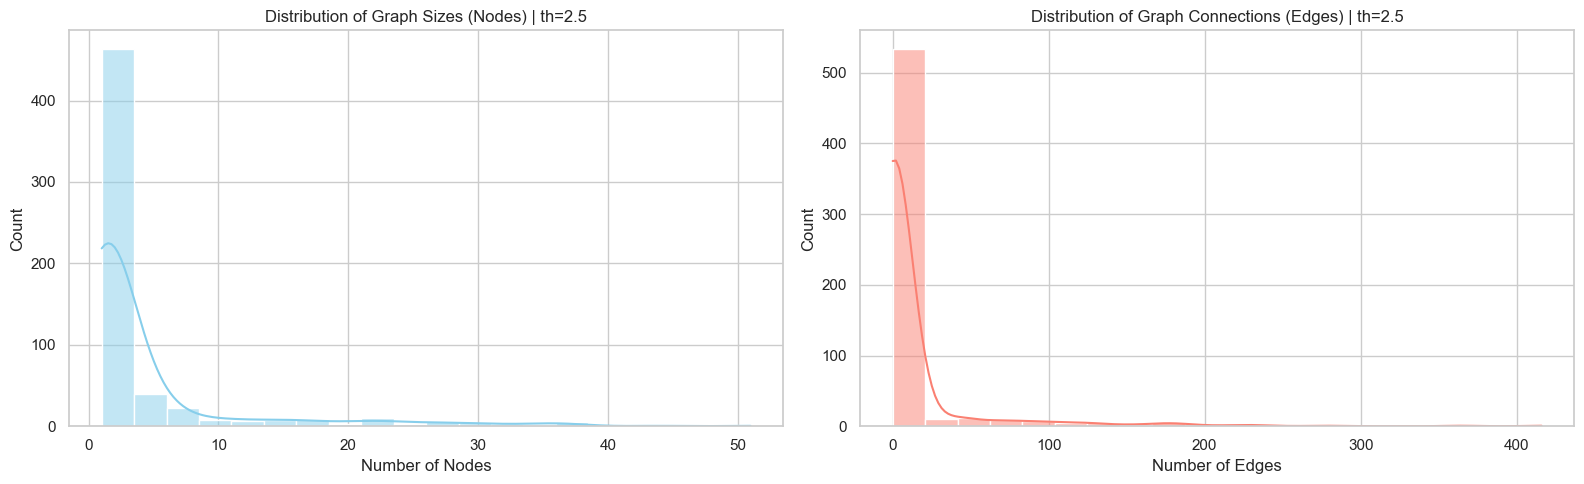

In [32]:
# Statistical distribution using a histogram
if graphs:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.histplot(df_stats['NumNodes'], bins=20, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution of Graph Sizes (Nodes) | th={threshold}')
    axes[0].set_xlabel('Number of Nodes')
    
    sns.histplot(df_stats['NumEdges'], bins=20, kde=True, ax=axes[1], color='salmon')
    axes[1].set_title(f'Distribution of Graph Connections (Edges) | th={threshold}')
    axes[1].set_xlabel('Number of Edges')
    
    plt.tight_layout()
    plt.show()

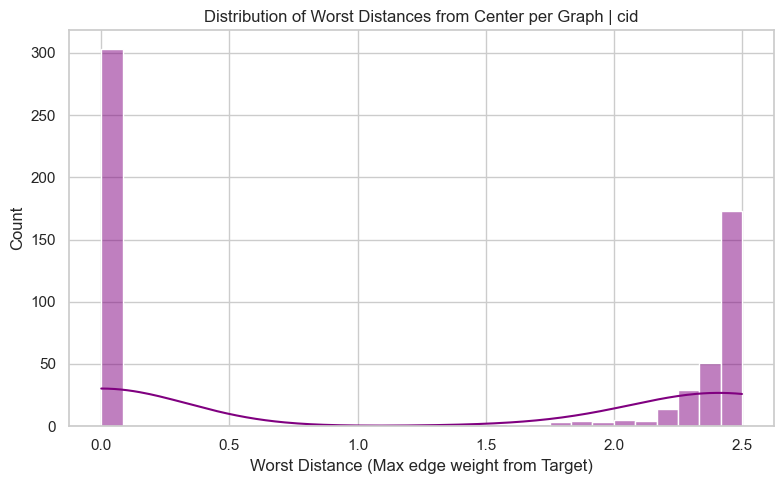

In [33]:
if graphs:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    sns.histplot(df_stats['WorstDistance'], bins=30, kde=True, ax=ax, color='purple')
    ax.set_title(f'Distribution of Worst Distances from Center per Graph | {metric}')
    ax.set_xlabel('Worst Distance (Max edge weight from Target)')
    
    plt.tight_layout()
    plt.show()

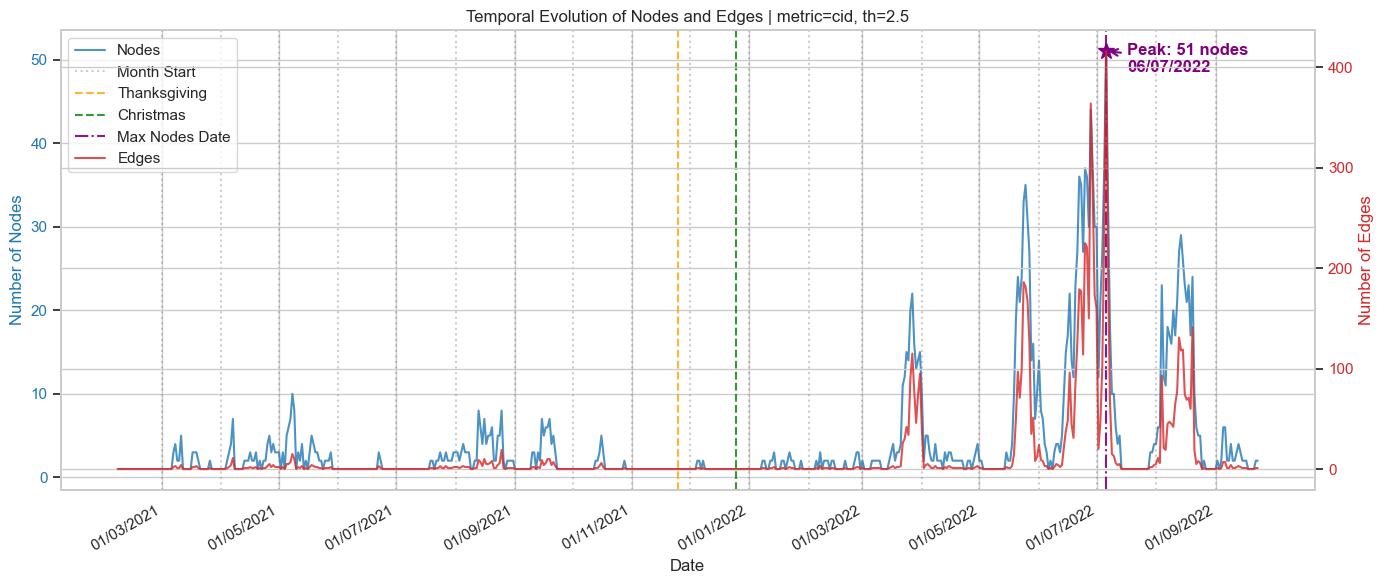

In [34]:
import matplotlib.dates as mdates

if graphs:
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    color = 'tab:blue'
    x_col = 'Date' if 'Date' in df_stats.columns else 'TimeStep'
    
    # Ensure datetime format for exact plotting
    if x_col == 'Date':
        df_stats['Date'] = pd.to_datetime(df_stats['Date'])
    
    ax1.set_xlabel('Date' if x_col == 'Date' else 'Window Step (Time)')
    ax1.set_ylabel('Number of Nodes', color=color)
    ax1.plot(df_stats[x_col], df_stats['NumNodes'], color=color, alpha=0.8, label='Nodes')
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Create a second y-axis to share the same x-axis
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Number of Edges', color=color)
    ax2.plot(df_stats[x_col], df_stats['NumEdges'], color=color, alpha=0.8, label='Edges')
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Force real date formatting on the x-axis and highlight features
    if x_col == 'Date':
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
        fig.autofmt_xdate()
        
        added_christmas_label = False
        added_month_label = False
        added_thanksgiving_label = False
        
        # Iterate over unique dates to place vertical lines
        for d in df_stats['Date'].dt.date.unique():
            d_obj = pd.to_datetime(d)
            if d_obj.day == 25 and d_obj.month == 12:
                # Highlight Christmas
                ax1.axvline(d_obj, color='green', linestyle='--', alpha=0.8, 
                            label='Christmas' if not added_christmas_label else "")
                added_christmas_label = True
            elif d_obj.month == 11 and d_obj.weekday() == 3 and 22 <= d_obj.day <= 28:
                # Highlight Thanksgiving (4th Thursday of November)
                ax1.axvline(d_obj, color='orange', linestyle='--', alpha=0.8, 
                            label='Thanksgiving' if not added_thanksgiving_label else "")
                added_thanksgiving_label = True
            elif d_obj.day == 1:
                # Highlight Month Beginnings
                ax1.axvline(d_obj, color='gray', linestyle=':', alpha=0.4, 
                            label='Month Start' if not added_month_label else "")
                added_month_label = True
                
        # Highlight Max Nodes Date
        max_idx = df_stats['NumNodes'].idxmax()
        max_date = df_stats.iloc[max_idx][x_col]
        max_nodes = df_stats.iloc[max_idx]['NumNodes']
        
        ax1.axvline(max_date, color='purple', linestyle='-.', alpha=0.9, label='Max Nodes Date')
        ax1.plot(max_date, max_nodes, marker='*', markersize=12, color='purple')
        
        # Add a text annotation pointing to the max peak
        ax1.annotate(f'Peak: {int(max_nodes)} nodes\n{max_date.strftime("%d/%m/%Y")}', 
                     xy=(max_date, max_nodes),
                     xytext=(15, -15), textcoords='offset points', 
                     color='purple', fontweight='bold',
                     arrowprops=dict(arrowstyle="->", color='purple', lw=1.5))
                
        # Consolidate legends from both axes and lines securely
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
        
    plt.title(f'Temporal Evolution of Nodes and Edges | metric={metric}, th={threshold}')
    fig.tight_layout()
    plt.show()

In [35]:
'''
import sys
sys.path.append(os.path.abspath('.'))
from graph_plot import plot_networkx_plotly

if graphs:
    # Use the respective GraphPlots directory to match your project structure
    plots_dir = f"GraphPlots/window_{window_size}/step_{step}/item_{product_id}/{metric}/th{threshold}"
    os.makedirs(plots_dir, exist_ok=True)
    
    skipped_count = 0
    for i, g in enumerate(graphs):
        save_path = os.path.join(plots_dir, f"graph_window_{i}.html")
        
        # Check if the plot already exists to avoid redundant building
        if os.path.exists(save_path):
            skipped_count += 1
            continue
            
        title = f"Graph Window {i} | item={product_id} | {metric} th={threshold}"
        
        # We pass target_node=int(product_id) to highlight the main item in red
        plot_networkx_plotly(g, title=title, save_path=save_path, target_node=int(product_id))
        print(f"Saved interactive plot for window {i} at: {save_path}")
        
    if skipped_count > 0:
        print(f"Skipped {skipped_count} graph plots because they already exist at: {plots_dir}")
        '''

'\nimport sys\nsys.path.append(os.path.abspath(\'.\'))\nfrom graph_plot import plot_networkx_plotly\n\nif graphs:\n    # Use the respective GraphPlots directory to match your project structure\n    plots_dir = f"GraphPlots/window_{window_size}/step_{step}/item_{product_id}/{metric}/th{threshold}"\n    os.makedirs(plots_dir, exist_ok=True)\n\n    skipped_count = 0\n    for i, g in enumerate(graphs):\n        save_path = os.path.join(plots_dir, f"graph_window_{i}.html")\n\n        # Check if the plot already exists to avoid redundant building\n        if os.path.exists(save_path):\n            skipped_count += 1\n            continue\n\n        title = f"Graph Window {i} | item={product_id} | {metric} th={threshold}"\n\n        # We pass target_node=int(product_id) to highlight the main item in red\n        plot_networkx_plotly(g, title=title, save_path=save_path, target_node=int(product_id))\n        print(f"Saved interactive plot for window {i} at: {save_path}")\n\n    if skipped_count